In [1]:
# Load packages

%pip install pandas
import pandas as pd

%pip install numpy
import numpy as np

%pip install matplotlib
import matplotlib as plt

%pip install matplotlib.figure
import matplotlib.figure as plt
import matplotlib.pyplot as plt

%pip install seaborn
import seaborn as sns

%pip install xgboost
import xgboost as XGBRegressor


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

%pip install linearmodels
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

%pip install shap
import shap



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement matplotlib.figure (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
ERROR: No matching distribution found for matplotlib.figure
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --

In [2]:
df = pd.read_csv("df.csv")

In [3]:
panel_df = df.copy()

In [4]:
# Set multi index
panel_df = panel_df.set_index(["geo", "year"])

In [5]:
features = [
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "log_gdp",
    "health_exp",
    "pm25_deaths"
]

# Simple pooled regression

In [6]:
# Create log gdp
panel_df["log_gdp"] = np.log(panel_df["gdp"])

In [7]:
model_cols = [
    "geo",
    "year",
    "healthy_life_years",
    "health_gap",
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "health_exp",
    "log_gdp",
    "pm25_deaths"
]

In [8]:
# define predictors
X = panel_df[[
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "health_exp",
    "log_gdp",
    "pm25_deaths"
]]

X = sm.add_constant(X)

In [9]:
# Fit pooled model, with outcome: Healthy life years 
pooled_model = PanelOLS(
    panel_df["healthy_life_years"],
    X,
    entity_effects=False,
    time_effects=False
)

pooled_results = pooled_model.fit()

print(pooled_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     healthy_life_years   R-squared:                        0.4719
Estimator:                   PanelOLS   R-squared (Between):              0.5095
No. Observations:                 189   R-squared (Within):               0.1819
Date:                Sat, May 23 2026   R-squared (Overall):              0.4719
Time:                        20:39:16   Log-likelihood                   -502.69
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      23.108
Entities:                          27   P-value                           0.0000
Avg Obs:                       7.0000   Distribution:                   F(7,181)
Min Obs:                       7.0000                                           
Max Obs:                       7.0000   F-statistic (robust):             23.108
                            

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


# Fixed effects model

In [10]:
fe_model = PanelOLS(
    panel_df["healthy_life_years"],
    X,
    entity_effects=True,
    time_effects=True
)

fe_results = fe_model.fit(cov_type="clustered",
                          cluster_entity=True)

print(fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     healthy_life_years   R-squared:                        0.3108
Estimator:                   PanelOLS   R-squared (Between):              0.0915
No. Observations:                 189   R-squared (Within):              -0.0402
Date:                Sat, May 23 2026   R-squared (Overall):              0.0764
Time:                        20:39:16   Log-likelihood                   -320.69
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      9.5978
Entities:                          27   P-value                           0.0000
Avg Obs:                       7.0000   Distribution:                   F(7,149)
Min Obs:                       7.0000                                           
Max Obs:                       7.0000   F-statistic (robust):             6.8211
                            

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


## Compare with health gap

In [11]:
panel_df["health_gap"]

geo  year
AT   2016    24.8
     2017    24.6
     2018    24.9
     2019    24.7
     2020    22.6
             ... 
UK   2018    20.1
     2019     NaN
     2020     NaN
     2021     NaN
     2022     NaN
Name: health_gap, Length: 210, dtype: float64

In [12]:
fe_model2 = PanelOLS(
    panel_df["health_gap"],
    X,
    entity_effects=True,
    time_effects=True
)

fe_results2 = fe_model2.fit(cov_type="clustered",
                          cluster_entity=True)

print(fe_results2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             health_gap   R-squared:                        0.3413
Estimator:                   PanelOLS   R-squared (Between):             -0.5670
No. Observations:                 182   R-squared (Within):               0.1529
Date:                Sat, May 23 2026   R-squared (Overall):             -0.4467
Time:                        20:39:16   Log-likelihood                   -314.73
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      10.586
Entities:                          26   P-value                           0.0000
Avg Obs:                       7.0000   Distribution:                   F(7,143)
Min Obs:                       7.0000                                           
Max Obs:                       7.0000   F-statistic (robust):             5.5227
                            

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


In [14]:
coef_df = pd.DataFrame({
    "variable": fe_results.params.index,
    "coef": fe_results.params.values,
    "lower": fe_results.conf_int().iloc[:, 0],
    "upper": fe_results.conf_int().iloc[:, 1]
})

coef_df = coef_df[coef_df["variable"] != "const"]

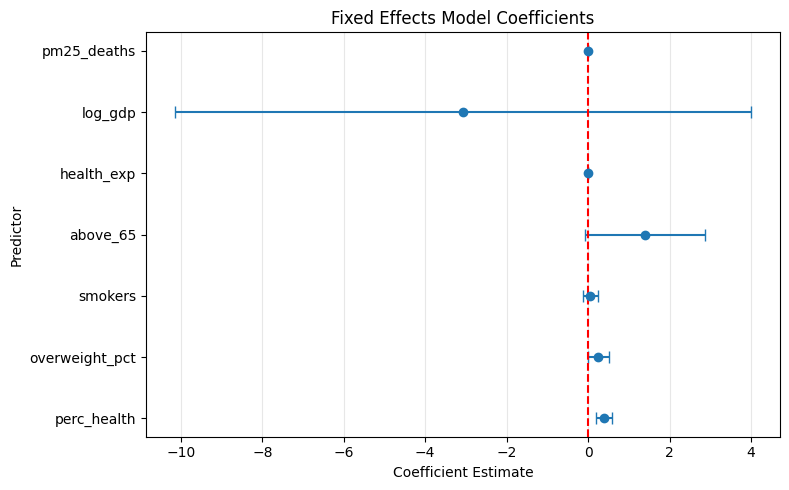

In [15]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    coef_df["coef"],
    coef_df["variable"],
    xerr=[
        coef_df["coef"] - coef_df["lower"],
        coef_df["upper"] - coef_df["coef"]
    ],
    fmt='o',
    capsize=4
)

plt.axvline(0, color='red', linestyle='--')

plt.xlabel("Coefficient Estimate")
plt.ylabel("Predictor")
plt.title("Fixed Effects Model Coefficients")

plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

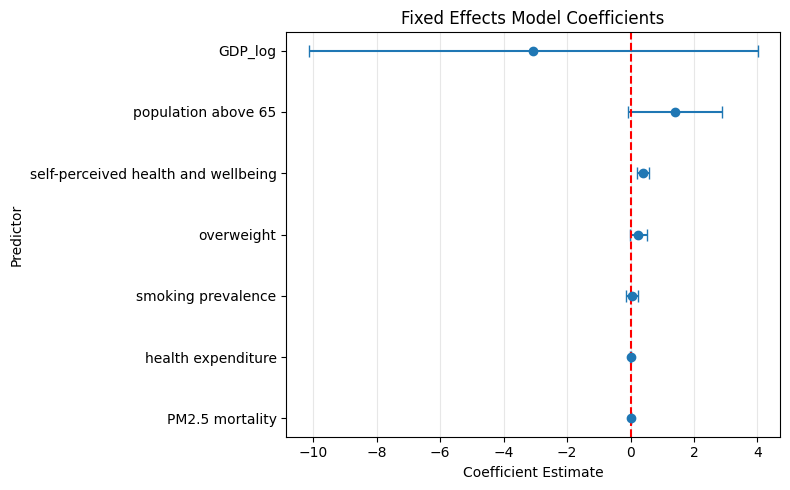

In [64]:
# Make names more readable in plot
pretty_names = {
    "perc_health": "self-perceived health and wellbeing",
    "pm25_deaths": "PM2.5 mortality",
    "health_exp": "health expenditure",
    "above_65": "population above 65",
    "overweight_pct": "overweight",
    "log_gdp": "GDP_log",
    "smokers": "smoking prevalence"
}

# Create readable labels
coef_df["variable_pretty"] = coef_df["variable"].replace(pretty_names)

# Sort by absolute coefficient magnitude
coef_df_sorted = coef_df.reindex(
    coef_df["coef"].abs().sort_values().index
)

# Plot
plt.figure(figsize=(8, 5))

plt.errorbar(
    coef_df_sorted["coef"],
    coef_df_sorted["variable_pretty"],
    xerr=[
        coef_df_sorted["coef"] - coef_df_sorted["lower"],
        coef_df_sorted["upper"] - coef_df_sorted["coef"]
    ],
    fmt='o',
    capsize=4
)

plt.axvline(0, color='red', linestyle='--')

plt.xlabel("Coefficient Estimate")
plt.ylabel("Predictor")
plt.title("Fixed Effects Model Coefficients")

plt.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ML Model
#### Target 1: Healthy life years
#### Target 2: Health gap

In [16]:
features = [
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "health_exp",
    "log_gdp",
    "pm25_deaths"
]

In [17]:
ml_df = (panel_df
    .dropna()
    .copy()
)

# Train/test split

In [18]:
# Check column names first
panel_df.columns.tolist()

['health_exp',
 'gdp',
 'smokers',
 'med_att',
 'perc_health',
 'antibiotics_DD',
 'overweight_pct',
 'above_65',
 'life_expectancy',
 'pm25_deaths',
 'healthy_life_years',
 'health_gap',
 'log_gdp']

In [19]:
panel_df = panel_df.reset_index()

panel_df["log_gdp"] = np.log(panel_df["gdp"])

features = [
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "health_exp",
    "log_gdp",
    "pm25_deaths"
]

ml_cols = features + [
    "healthy_life_years",
    "health_gap",
    "year"
]

missing = [col for col in ml_cols if col not in panel_df.columns]
print(missing)

ml_df = panel_df[ml_cols].dropna().copy()
ml_df.head()

[]


,perc_health,overweight_pct,smokers,above_65,health_exp,log_gdp,pm25_deaths,healthy_life_years,health_gap,year
0,70.3,50.000000,28.0,18.4,4281.48,10.501915,3911.0,57.0,24.8,2016
1,70.4,50.000000,28.0,18.5,4413.49,10.519003,4184.0,57.1,24.6,2017
2,71.7,51.100000,27.0,18.7,4558.54,10.556318,4981.0,56.9,24.9,2018
3,71.3,52.200000,26.0,18.8,4734.85,10.578058,3694.0,57.3,24.7,2019
4,74.0,52.366667,25.0,19.0,4867.79,10.529041,3152.0,58.7,22.6,2020


In [20]:
features = [
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "health_exp",
    "log_gdp",
    "pm25_deaths"
]

# make sure log_gdp exists
if "log_gdp" not in panel_df.columns:
    panel_df["log_gdp"] = np.log(panel_df["gdp"])

ml_cols = features + [
    "healthy_life_years",
    "health_gap",
    "year"
]

ml_df = (
    panel_df[ml_cols]
    .dropna()
    .copy()
)

ml_df.head()

,perc_health,overweight_pct,smokers,above_65,health_exp,log_gdp,pm25_deaths,healthy_life_years,health_gap,year
0,70.3,50.000000,28.0,18.4,4281.48,10.501915,3911.0,57.0,24.8,2016
1,70.4,50.000000,28.0,18.5,4413.49,10.519003,4184.0,57.1,24.6,2017
2,71.7,51.100000,27.0,18.7,4558.54,10.556318,4981.0,56.9,24.9,2018
3,71.3,52.200000,26.0,18.8,4734.85,10.578058,3694.0,57.3,24.7,2019
4,74.0,52.366667,25.0,19.0,4867.79,10.529041,3152.0,58.7,22.6,2020


In [21]:
# ML df

ml_df = (
    panel_df[
        features +
        ["healthy_life_years", "health_gap", "year"]
    ]
    .dropna()
    .copy()
)

In [22]:
# Split train and test, time

train_df = ml_df[ml_df["year"] <= 2020]
test_df  = ml_df[ml_df["year"] > 2020]

In [23]:
# Create X and Y

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df["healthy_life_years"]
y_test = test_df["healthy_life_years"]

## Baseline linear regression

In [24]:
# Baseline linear reg

linreg = LinearRegression()

linreg.fit(X_train, y_train)

pred_lr = linreg.predict(X_test)

In [25]:
# Evaluate
print("Linear Regression")

print("MAE:",
      mean_absolute_error(y_test, pred_lr))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_lr)))

print("R2:",
      r2_score(y_test, pred_lr))

Linear Regression
MAE: 2.6594929364655497
RMSE: 3.2730286327928897
R2: 0.31807435737162226


## Random forest modelling

In [26]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [27]:
print("Random Forest")

print("MAE:",
      mean_absolute_error(y_test, pred_rf))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_rf)))

print("R2:",
      r2_score(y_test, pred_rf))

Random Forest
MAE: 2.120189091905408
RMSE: 2.7593419385538684
R2: 0.5153274139520563


## XGB

In [ ]:
# XGBoost model

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)


In [ ]:
# Print model outcomes

print("XGBoost")

print("MAE:",
      mean_absolute_error(y_test, pred_xgb))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, pred_xgb)))

print("R2:",
      r2_score(y_test, pred_xgb))

XGBoost
MAE: 2.126766410240761
RMSE: 2.6816923299801942
R2: 0.5422215838730663


## Compare results

In [ ]:
# Compare results across linear model, Random Forest, and XGBoost

results = pd.DataFrame({
    "Model": ["Linear", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_xgb))
    ],
    "R2": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_xgb)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear,2.659493,3.273029,0.318074
1,Random Forest,2.120189,2.759342,0.515327
2,XGBoost,2.126766,2.681692,0.542222


# Feature importance

<Axes: >

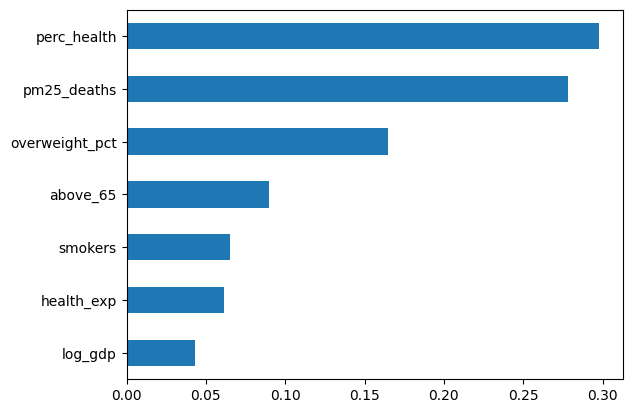

In [ ]:
# Fit model and plot feature importance

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values()

importance.plot(kind="barh")

# Shap analysis

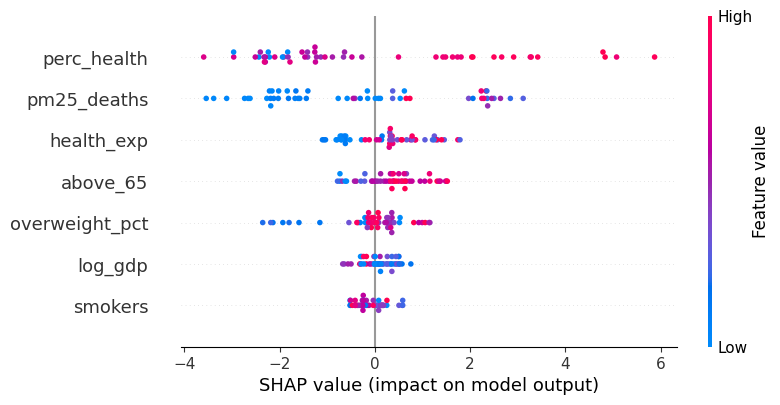

In [ ]:
# Plot SHAP 

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

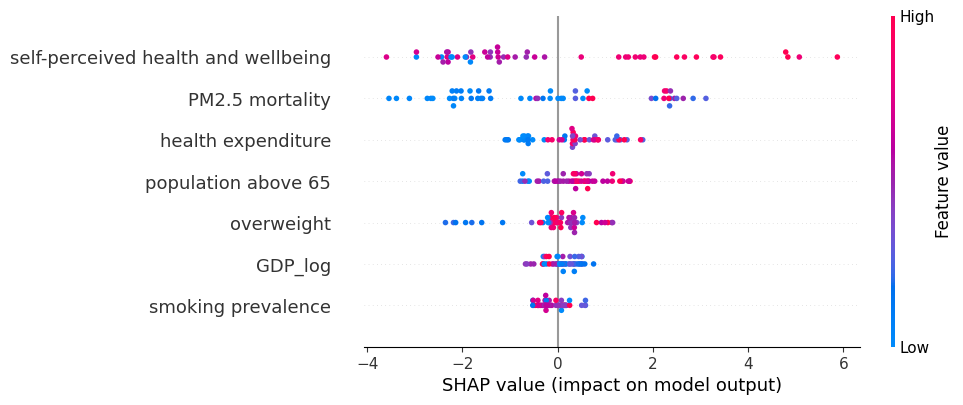

In [62]:
# Create readable feature names
pretty_names = {
    "perc_health": "self-perceived health and wellbeing",
    "pm25_deaths": "PM2.5 mortality",
    "health_exp": "health expenditure",
    "above_65": "population above 65",
    "overweight_pct": "overweight",
    "log_gdp": "GDP_log",
    "smokers" : "smoking prevalence"
}

# Rename columns
X_test_pretty = X_test.rename(columns=pretty_names)

# Recompute SHAP values with renamed columns
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_pretty)

# Plot
shap.plots.beeswarm(shap_values)

# PHASE 4: Forecasting/scenarios

In [34]:
baseline_pred = xgb_model.predict(X_test)

In [53]:
# Increase perceived health by 5 percentage points 
#scenario_df = X_test.copy()

#scenario_df["pm25_deaths"] -= 5

# Create scenario dataset
scenario_df = X_test.copy()

# Reduce PM2.5 deaths by 20%
scenario_df["pm25_deaths"] *= 0.80

# Reduce overweight percentage by 10%
scenario_df["overweight_pct"] *= 0.90

In [54]:
# Predict scenario outcome
scenario_pred = xgb_model.predict(scenario_df)

In [55]:
# Compute differences 
difference = scenario_pred - baseline_pred

In [56]:
# Create results dataframe
scenario_results = pd.DataFrame({
    "baseline": baseline_pred,
    "scenario": scenario_pred,
    "difference": difference
})

scenario_results.head()

,baseline,scenario,difference
0,59.344685,60.741600,1.396915
1,59.306240,59.846577,0.540337
2,61.598118,63.980648,2.382530
3,62.145035,64.104439,1.959404
4,65.493019,65.386795,-0.106224


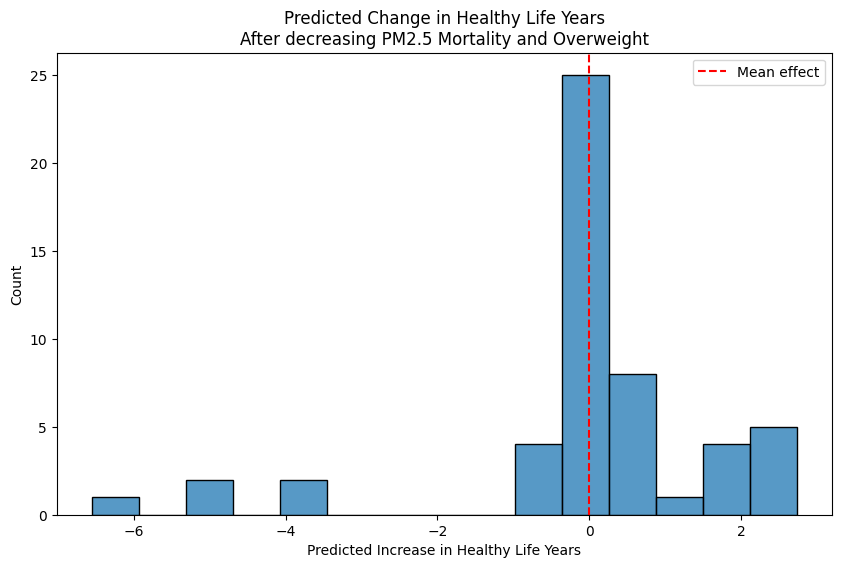

In [58]:
# Plot differences
plt.figure(figsize=(10, 6))

sns.histplot(
    scenario_results["difference"],
    bins=15
)

plt.axvline(
    scenario_results["difference"].mean(),
    color="red",
    linestyle="--",
    label="Mean effect"
)

plt.title(
    "Predicted Change in Healthy Life Years\nAfter decreasing PM2.5 Mortality and Overweight"
)

plt.xlabel("Predicted Increase in Healthy Life Years")

plt.legend()

plt.show()

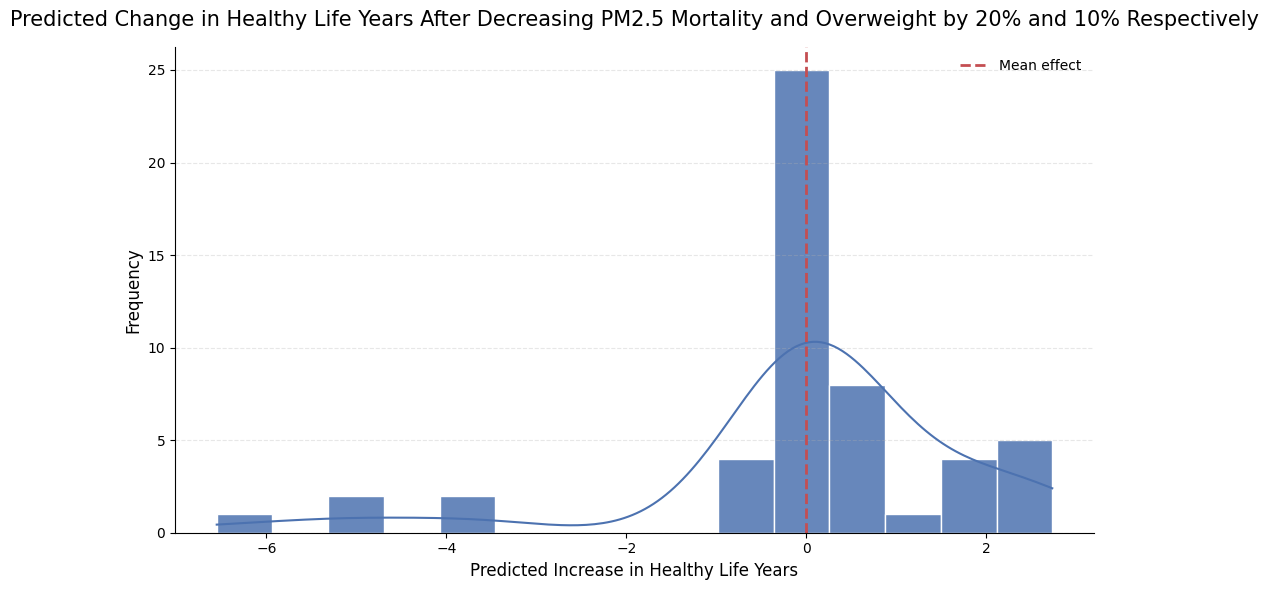

In [60]:
plt.figure(figsize=(10, 6))

sns.histplot(
    scenario_results["difference"],
    bins=15,
    kde=True,
    color="#4C72B0",      # soft blue
    edgecolor="white",
    alpha=0.85
)

plt.axvline(
    scenario_results["difference"].mean(),
    color="#C44E52",      # muted red
    linestyle="--",
    linewidth=2,
    label="Mean effect"
)

plt.title(
    "Predicted Change in Healthy Life Years After Decreasing PM2.5 Mortality and Overweight by 20% and 10% Respectively",
    fontsize=15,
    pad=15
)

plt.xlabel(
    "Predicted Increase in Healthy Life Years",
    fontsize=12
)

plt.ylabel(
    "Frequency",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(frameon=False)

sns.despine()

plt.tight_layout()
plt.show()

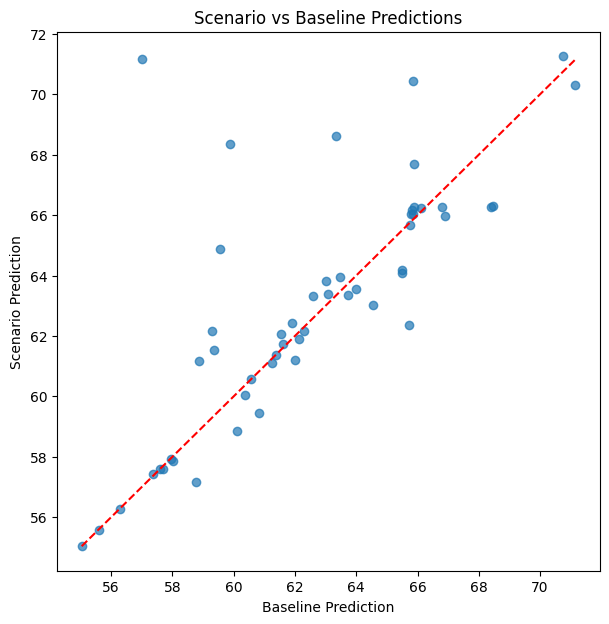

In [42]:
# Baseline vs scenario
plt.figure(figsize=(7, 7))

plt.scatter(
    baseline_pred,
    scenario_pred,
    alpha=0.7
)

plt.plot(
    [baseline_pred.min(), baseline_pred.max()],
    [baseline_pred.min(), baseline_pred.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Baseline Prediction")
plt.ylabel("Scenario Prediction")

plt.title("Scenario vs Baseline Predictions")

plt.show()